In [1]:
import Pkg
Pkg.activate(joinpath(@__DIR__, ".."))

# Force PauliPropagation to the version MajoranaPropagation expects.
Pkg.add(Pkg.PackageSpec(name="PauliPropagation", version="0.7.2"))

Pkg.instantiate()
Pkg.resolve()

using Revise
using MajoranaPropagation
using PauliPropagation
using Plots 
using Printf

  Activating project at `~/prof/work/lucj/MajoranaPropagation.jl`
   Resolving package versions...
      Compat entries added for 
     Project No packages added to or removed from `~/prof/work/lucj/MajoranaPropagation.jl/Project.toml`
    Manifest No packages added to or removed from `~/prof/work/lucj/MajoranaPropagation.jl/Manifest.toml`
     Project No packages added to or removed from `~/prof/work/lucj/MajoranaPropagation.jl/Project.toml`
    Manifest No packages added to or removed from `~/prof/work/lucj/MajoranaPropagation.jl/Manifest.toml`


## Parameters

In [42]:
circuit_fname = "lucj_hchain_40_atoms.json"

"lucj_hchain_40_atoms.json"

# Defining the LUCJ Ansatz gates as Hamiltonians composed of Majorana strings

In [43]:
# ════════════════════════════════════════════════════════════════════════
#  Custom Majorana symbols for LUCJ circuit construction
# ════════════════════════════════════════════════════════════════════════
#
#  This file registers two new Majorana symbols with MajoranaPropagation:
#
#    :matchgate_theta   →  generator of the pure hopping (XX+YY) gate
#    :phase_qubit       →  generator of single-qubit phase / Rz gate
#
#  Each symbol defines a Hamiltonian H expressed as a sum of Majorana
#  operator strings.  When MP later sees `FermionicGate(symbol, sites)`
#  applied with angle θ, it constructs the unitary:
#
#       U = exp(-i θ · H)
#
#  and applies it in the Heisenberg picture by walking the Majorana
#  rotations in H one at a time.
#
#  These symbols are sufficient to assemble Qiskit's XXPlusYYGate, p(φ),
#  and Rz(α) — the only gate types the LUCJ ansatz uses.
# ════════════════════════════════════════════════════════════════════════

#import MajoranaPropagation
const MP = MajoranaPropagation


# ────────────────────────────────────────────────────────────────────────
#  :matchgate_theta — pure hopping matchgate (Qiskit XXPlusYYGate(θ, 0))
# ────────────────────────────────────────────────────────────────────────
#
#  We want a gate whose action on Majorana strings reproduces:
#
#      G(θ, 0) = exp[-i (θ/4) · (X_i X_j + Y_i Y_j)]
#
#  In second quantization this is exp[-i (θ/2) · (c†_i c_j + c†_j c_i)],
#  which under Jordan-Wigner becomes a hopping between qubits i and j.
#  In our spinless Majorana convention (qubit q has γ at MP-bit (2q+1)
#  and γ' at MP-bit (2q+2)) the hopping Hamiltonian is:
#
#      H_θ = ½ · γ_{2i+1} γ_{2j+2}  −  ½ · γ_{2i+2} γ_{2j+1}
#
#  Two weight-2 Majorana strings with opposite signs.  Their indices are
#  disjoint, so the two strings commute, and MP's exponentiation of their
#  sum factorizes exactly into a product of two Majorana rotations.
#
#  IMPORTANT: when calling `FermionicGate(:matchgate_theta, [i, j])`,
#  the angle passed must be θ/2, not θ — because MP applies exp(-i·angle·H)
#  and our H already absorbs a factor of 2 relative to Qiskit's convention.
#
function MP.MajoranaSum(n_qubits::Integer, ::Val{:matchgate_theta}, ij)
    i, j = ij
    is_spinful = false                              # spinless Majorana layout
    obs = MP.MajoranaSum(n_qubits,
                         [2i + 1, 2j + 2],          # bits for γ_i γ'_j
                         is_spinful;
                         coeff =  0.5)
    MP.add!(obs,
            MP.MajoranaSum(n_qubits,
                           [2i + 2, 2j + 1],        # bits for γ'_i γ_j
                           is_spinful;
                           coeff = -0.5))
    return obs
end


# ────────────────────────────────────────────────────────────────────────
#  :phase_qubit — single-qubit phase gate generator
# ────────────────────────────────────────────────────────────────────────
#
#  Implements the number operator on qubit q (0-indexed):
#
#      n_q = ½ · γ_{2q+1} γ_{2q+2}  +  ½ · I
#
#  So the gate `FermionicGate(:phase_qubit, q)` with angle θ applies:
#
#      exp(-i θ · n_q)
#
#  This single primitive serves two roles in the LUCJ pipeline:
#
#    1. Qiskit's p(φ) = diag(1, e^{iφ}) = exp(+i φ · n_q).
#       To realize p(φ), pass angle = -φ to phase_qubit.
#
#    2. Decomposition piece for Qiskit's XXPlusYYGate(θ, β):
#          XX+YY(θ, β) = Rz_j(β) · XX+YY(θ, 0) · Rz_j(-β)        (up to global phase)
#       and Rz_j(α) = exp(-iα Z_j / 2) ≡ exp(+iα · n_j) modulo global phase,
#       so each Rz_j(α) is realized as `phase_qubit(j)` with angle = -α.
#
#  Both uses were validated empirically against Qiskit sampling
#  (|0101⟩ ≈ 0.989 matching Qiskit's 99k/100k counts).
#
function MP.MajoranaSum(n_qubits::Integer, ::Val{:phase_qubit}, q)
    qq = q isa AbstractVector ? q[1] : q            # accept either q or [q]
    is_spinful = false
    obs = MP.MajoranaSum(n_qubits,
                         [2qq + 1, 2qq + 2],        # γ_q γ'_q  (the n_q core)
                         is_spinful;
                         coeff = 0.5)
    MP.add!(obs, 0, 0.5)                            # add the +½·I identity term
    return obs
end


# ────────────────────────────────────────────────────────────────────────
#  Truncation flags
# ────────────────────────────────────────────────────────────────────────
#
#  Tells MP whether each individual Majorana rotation in the gate's
#  decomposition would, in isolation, fail to preserve particle number.
#  When this is true, MP suppresses intermediate truncations between
#  the rotations of one gate, since number conservation only re-emerges
#  after the full gate is applied.
#
#    :matchgate_theta  → individual rotations are non-number-preserving,
#                         flag = true  (matches MP's built-in :hop)
#    :phase_qubit      → just rotates n_q, always number-preserving,
#                         flag defaults to false (no entry needed)
#
MP.flag_non_number_preserving(::Val{:matchgate_theta}) = true

In [44]:
# ════════════════════════════════════════════════════════════════════════
#  orbital_rotation! — append MP gates implementing a Qiskit orbital rotation
# ════════════════════════════════════════════════════════════════════════
#
#  An "orbital rotation" is a single-particle unitary U acting on `norb`
#  spatial orbitals.  In a spinful electronic system it is applied
#  independently to the spin-up and spin-down sectors.  ffsim factors U
#  into a sequence of two-orbital Givens rotations followed by a per-orbital
#  diagonal of phase shifts:
#
#       U = (∏ Givens(θ_k, β_k, i_k, j_k))  ·  diag(e^{iφ_1}, e^{iφ_2}, ...)
#
#  Qiskit realizes each Givens(θ, β, i, j) as `XXPlusYYGate(θ, β)` acting
#  on qubits (i, j), and each phase e^{iφ_p} as `p(φ_p)` on qubit p.  This
#  function appends MP-equivalent gates for both spin sectors to (gates, thetas).
#
#  Qubit layout convention:
#       qubits 0      .. norb-1   →  spin-up  on spatial orbitals 1..norb
#       qubits norb   .. 2norb-1  →  spin-down on spatial orbitals 1..norb
#
#  Inputs (per ffsim's `givens_decomposition` convention):
#       givens_rotations :: Vector of NamedTuple-like (c, s, i, j) where
#               c  = cos(θ/2)              (real Float64)
#               s  = sin(θ/2)·e^{iβ + iπ/2}  (complex Float64; the +iπ/2
#                       offset is ffsim's convention, undone below as
#                       β = angle(s) - π/2)
#               i, j = qubit indices, 0-based, with j > i
#
#       phase_shifts     :: Vector{ComplexF64} of length norb, each unit-modulus,
#                            giving e^{iφ_p} for p = 1..norb
#
#       norb             :: number of spatial orbitals (so 2*norb qubits total)
#
#  Mutates `gates` and `thetas` in-place by appending; returns them too.
# ════════════════════════════════════════════════════════════════════════

function orbital_rotation!(gates, thetas,
                            givens_rotations, phase_shifts,
                            norb::Integer)

    # ── Givens rotations on every (i, j) pair, applied to BOTH spin sectors ──
    #
    #  Each Givens rotation is the Qiskit `XXPlusYYGate(θ, β)`, which factors as
    #
    #       G(θ, β) = Rz_j(+β) · G(θ, 0) · Rz_j(-β)
    #
    #  (this is the empirically validated "Combo C" sign convention — Qiskit's
    #  Rz(α) corresponds to MP's phase_qubit(q) at angle +α, NOT -α.)
    #
    #  G(θ, 0) is pure hopping and is realized by `matchgate_theta` at angle θ/2
    #  (the /2 because :matchgate_theta's generator H_θ already absorbs a
    #  factor of 2 relative to Qiskit's normalization).
    #
    for (c, s, i, j) in givens_rotations
        θ = 2 * acos(clamp(real(c), -1.0, 1.0))
        β = angle(s) - 0.5 * π

        # ── spin-up sector: qubits (i, j) ────────────────────────────────
        push!(gates, MP.FermionicGate(:phase_qubit,    j));          push!(thetas, +β)
        push!(gates, MP.FermionicGate(:matchgate_theta, [i, j]));     push!(thetas, θ/2)
        push!(gates, MP.FermionicGate(:phase_qubit,    j));          push!(thetas, -β)

        # ── spin-down sector: qubits (i+norb, j+norb) ────────────────────
        push!(gates, MP.FermionicGate(:phase_qubit,    j + norb));   push!(thetas, +β)
        push!(gates, MP.FermionicGate(:matchgate_theta, [i+norb, j+norb])); push!(thetas, θ/2)
        push!(gates, MP.FermionicGate(:phase_qubit,    j + norb));   push!(thetas, -β)
    end

    # ── Per-orbital phase shifts on each spin sector ──────────────────────
    #
    #  Each `phase_shifts[idx]` is a complex unit-modulus number e^{iφ}.
    #  Qiskit's p(φ) = diag(1, e^{iφ}) = exp(+iφ · n_q).  Our :phase_qubit
    #  realizes exp(-i·angle·n_q), so we pass `angle = -φ` to invert the sign.
    #
    #  Skip near-identity rotations (|φ| < 1e-14) — they're round-off and
    #  emitting them just bloats the gate count without changing the result.
    #
    for (idx, ph) in enumerate(phase_shifts)
        φ = angle(ph)
        abs(φ) < 1e-14 && continue

        q = idx - 1                  # convert 1-based orbital → 0-based qubit

        push!(gates, MP.FermionicGate(:phase_qubit, q));         push!(thetas, -φ)
        push!(gates, MP.FermionicGate(:phase_qubit, q + norb));  push!(thetas, -φ)
    end

    return gates, thetas
end

orbital_rotation! (generic function with 1 method)

In [45]:
# Controlled-phase Hamiltonian: H = n_i n_j, so FermionicGate with angle θ
# implements exp(-i θ n_i n_j).
function MP.MajoranaSum(n_qubits::Integer, ::Val{:cphase_qubit}, ij)
    @assert length(ij) == 2 "cphase_qubit needs [i, j]"
    i, j = ij                                     # 0-based qubit indices
    ni = MP.MajoranaSum(n_qubits, :n, i + 1)      # :n uses 1-based sites
    nj = MP.MajoranaSum(n_qubits, :n, j + 1)
    return ni * nj
end

In [46]:
# ════════════════════════════════════════════════════════════════════════
#  j_op! — append MP gates for one diagonal-Coulomb (J) block of LUCJ
# ════════════════════════════════════════════════════════════════════════
#
#  A LUCJ J-block implements the time-evolution under a diagonal Coulomb
#  Hamiltonian:
#
#       J_op = exp(-i · t · Ĵ)
#
#  where
#
#       Ĵ = ½ Σ_{i,σ} J^{σσ}_{ii} · n_{i,σ}                  ← per-site density
#         +   Σ_{i<j,σ} J^{σσ}_{ij} · n_{i,σ} n_{j,σ}        ← same-spin density-density
#         +   Σ_{ij}   J^{↑↓}_{ij} · n_{i,↑} n_{j,↓}        ← opposite-spin density-density
#
#  In Qiskit, this decomposes into:
#       • p(-0.5·J^{σσ}_{ii}·t, qubit_i)        — single-qubit phase
#       • cp(-J^{σσ}_{ij}·t, qubit_i, qubit_j)  — two-qubit controlled phase
#       • cp(-J^{↑↓}_{ij}·t, qubit_i, qubit_{j+norb}) for opposite-spin
#
#  Sign convention going from Qiskit angles to MP angles:
#       • Qiskit p(φ)  = exp(+iφ·n)        but MP :phase_qubit = exp(-iθ·n)
#         → MP θ = -φ.  For Qiskit angle -0.5·J·t, MP θ = +0.5·J·t.
#       • Qiskit cp(φ) = exp(+iφ·n_i·n_j)  but MP :cphase_qubit = exp(-iθ·n_i·n_j)
#         → MP θ = -φ.  For Qiskit angle -J·t, MP θ = +J·t.
#
#  Qubit layout (spinless MP, 2*norb qubits total):
#       qubits 0    .. norb-1   →  spin-up  on spatial orbitals 1..norb
#       qubits norb .. 2norb-1  →  spin-down on spatial orbitals 1..norb
#
#  Inputs:
#       diag_mat_aa :: norb × norb symmetric matrix of J^{↑↑} couplings
#                       (or `nothing` to skip the up-up block)
#       diag_mat_ab :: norb × norb (NOT necessarily symmetric) matrix of J^{↑↓}
#                       (or `nothing` to skip the opposite-spin block)
#       diag_mat_bb :: norb × norb symmetric matrix of J^{↓↓} couplings
#                       (or `nothing` to skip the down-down block; usually
#                        equal to diag_mat_aa for closed-shell systems)
#       time        :: scalar evolution time t
#       norb        :: number of spatial orbitals
#
#  Mutates `gates` and `thetas` in-place by appending; returns them too.
# ════════════════════════════════════════════════════════════════════════

function j_op!(gates, thetas,
               diag_mat_aa, diag_mat_ab, diag_mat_bb,
               time::Real, norb::Integer)

    coeff_threshold = 1e-14   # skip near-zero couplings to keep the circuit tight

    # ── Same-spin blocks ──────────────────────────────────────────────────
    #
    #  Iterate over (offset, J-matrix) pairs:
    #     spin-up   →  qubit offset = 0
    #     spin-down →  qubit offset = norb
    #
    for (offset, this_mat) in ((0, diag_mat_aa), (norb, diag_mat_bb))

        if this_mat === nothing
            continue   # skip silently if caller asked for no contribution here
        end

        # ── Diagonal couplings:  ½ J_{ii} · n_{i,σ} ─────────────────────
        # Qiskit:  p(-0.5·J·t, q)     →   MP :phase_qubit at angle +0.5·J·t
        for i in 1:norb
            J = this_mat[i, i]
            abs(J) < coeff_threshold && continue
            q = (i - 1) + offset                      # 0-based qubit index
            push!(gates,  MP.FermionicGate(:phase_qubit, q))
            push!(thetas, 0.5 * J * time)
        end

        # ── Off-diagonal couplings:  J_{ij} · n_{i,σ} n_{j,σ}, i < j ─────
        # Qiskit:  cp(-J·t, qi, qj)   →   MP :cphase_qubit at angle +J·t
        for i in 1:norb-1, j in i+1:norb
            J = this_mat[i, j]
            abs(J) < coeff_threshold && continue
            qi = (i - 1) + offset
            qj = (j - 1) + offset
            push!(gates,  MP.FermionicGate(:cphase_qubit, [qi, qj]))
            push!(thetas, J * time)
        end
    end

    # ── Opposite-spin block:  J^{↑↓}_{ij} · n_{i,↑} n_{j,↓} ───────────────
    #
    #  Both diagonal (i = j, "same orbital, opposite spin") and off-diagonal
    #  (i ≠ j) contributions.  Note that J_ab is generally NOT symmetric:
    #  the (i, j) entry couples up-i to down-j, while (j, i) couples up-j
    #  to down-i — both must be emitted.
    #
    if diag_mat_ab !== nothing

        # Diagonal: J_{ii} · n_{i,↑} n_{i,↓}
        for i in 1:norb
            J = diag_mat_ab[i, i]
            abs(J) < coeff_threshold && continue
            qi = i - 1
            qj = (i - 1) + norb
            push!(gates,  MP.FermionicGate(:cphase_qubit, [qi, qj]))
            push!(thetas, J * time)
        end

        # Off-diagonal: both (i, j) and (j, i) directions
        for i in 1:norb-1, j in i+1:norb
            J_ij = diag_mat_ab[i, j]    # up-i  ↔  down-j
            if abs(J_ij) >= coeff_threshold
                qi = i - 1
                qj = (j - 1) + norb
                push!(gates,  MP.FermionicGate(:cphase_qubit, [qi, qj]))
                push!(thetas, J_ij * time)
            end

            J_ji = diag_mat_ab[j, i]    # up-j  ↔  down-i
            if abs(J_ji) >= coeff_threshold
                qi = j - 1
                qj = (i - 1) + norb
                push!(gates,  MP.FermionicGate(:cphase_qubit, [qi, qj]))
                push!(thetas, J_ji * time)
            end
        end
    end

    return gates, thetas
end


# ════════════════════════════════════════════════════════════════════════
#  build_j_op — convenience wrapper returning a fresh (gates, thetas) pair
# ════════════════════════════════════════════════════════════════════════
function build_j_op(diag_mat_aa, diag_mat_ab, diag_mat_bb, time, norb)
    gates  = []
    thetas = Float64[]
    j_op!(gates, thetas, diag_mat_aa, diag_mat_ab, diag_mat_bb, time, norb)
    #                                              ^^^^^^^^^^^
    #  FIX: was passing `diag_mat_aa` twice; corrected to pass diag_mat_bb.
    return gates, thetas
end

build_j_op (generic function with 1 method)

In [47]:
# ═══════════════════════════════════════════════════════════════════
#  Top-level LUCJ driver — mirrors the Python ansatz construction
# ═══════════════════════════════════════════════════════════════════

"""
    build_lucj_circuit(orbital_rotation_data, diag_mats_data,
                       final_rotation_data, time, norb)

Mirror of the Python loop:

    for orb_rot, (diag_mat_aa, diag_mat_ab) in zip(orbital_rotations, diag_mats):
        orbital_rotation(qc, orb_rot.T.conj(), N)
        J_op(qc, diag_mat_aa, diag_mat_ab, diag_mat_aa, time, norb)
        orbital_rotation(qc, orb_rot, N)
    if ucj_op.final_orbital_rotation is not None:
        orbital_rotation(qc, ucj_op.final_orbital_rotation, N)

Arguments
---------
- orbital_rotation_data :: Vector of NamedTuples, one per layer, each with
      (fwd_givens, fwd_phases, inv_givens, inv_phases)
  where fwd_* is the Givens decomposition of `orb_rot.T.conj()`
  and inv_* is the Givens decomposition of `orb_rot`.
- diag_mats_data :: Vector of (diag_mat_aa, diag_mat_ab) tuples,
  same length as orbital_rotation_data.
- final_rotation_data :: Either `nothing` or a NamedTuple (givens, phases)
  with the Givens decomposition of `ucj_op.final_orbital_rotation`.
- time, norb :: numeric parameters (same as Python).
"""
function build_lucj_circuit(orbital_rotation_data,
                             diag_mats_data,
                             final_rotation_data,
                             time::Real,
                             norb::Integer)

    @assert length(orbital_rotation_data) == length(diag_mats_data) "orbital_rotation_data and diag_mats_data must have the same length"

    gates  = []
    thetas = Float64[]

    # Main loop: one (rot_fwd · J_op · rot_inv) sandwich per layer
    for (rot, (diag_aa, diag_ab)) in zip(orbital_rotation_data, diag_mats_data)
        orbital_rotation!(gates, thetas, rot.fwd_givens, rot.fwd_phases, norb)
        j_op!(gates, thetas, diag_aa, diag_ab, diag_aa, time, norb)
        orbital_rotation!(gates, thetas, rot.inv_givens, rot.inv_phases, norb)
    end

    if final_rotation_data !== nothing
        orbital_rotation!(gates, thetas,
                          final_rotation_data.givens,
                          final_rotation_data.phases,
                          norb)
    end

    return gates, thetas
end

build_lucj_circuit

# Importing LUCJ Initial parameters by running LUCJ_ansatz.ipynb for a chosen Hamiltonian

In [48]:
# ═══════════════════════════════════════════════════════════════════
#  LUCJ circuit parameters — loaded from Python-generated JSON
# ═══════════════════════════════════════════════════════════════════

import Pkg
# Uncomment the next line the FIRST time you run this on a new machine:
Pkg.add("JSON")
using JSON

"""
    load_lucj_params(filepath) -> (orbital_rotation_data, diag_mats_data,
                                     final_rotation_data, time, norb, nelectron)

Read the JSON dumped by Python's `dump_lucj_to_json` and return the tuple of
data structures your existing `build_lucj_circuit` expects.
"""
function load_lucj_params(filepath::AbstractString)
    raw = JSON.parsefile(filepath)

    norb      = Int(raw["norb"])
    time      = Float64(raw["time"])
    nelectron = haskey(raw, "nelectron") ? Int(raw["nelectron"]) : 2 * norb

    parse_givens(rots_json) = [
        (Float64(g["c"]),
         complex(Float64(g["s_re"]), Float64(g["s_im"])),
         Int(g["i"]), Int(g["j"]))
        for g in rots_json
    ]

    parse_phases(phases_json) = ComplexF64[
        complex(Float64(p[1]), Float64(p[2])) for p in phases_json
    ]

    parse_matrix(rows_json) =
        reduce(vcat, [permutedims(Float64.(row)) for row in rows_json])

    orbital_rotation_data = []
    diag_mats_data        = []

    for layer in raw["layers"]
        push!(orbital_rotation_data, (
            fwd_givens = parse_givens(layer["fwd"]["givens"]),
            fwd_phases = parse_phases(layer["fwd"]["phase_shifts"]),
            inv_givens = parse_givens(layer["inv"]["givens"]),
            inv_phases = parse_phases(layer["inv"]["phase_shifts"]),
        ))
        push!(diag_mats_data, (
            parse_matrix(layer["diag_mat_aa"]),
            parse_matrix(layer["diag_mat_ab"]),
        ))
    end

    final_rotation_data = nothing
    if raw["final"] !== nothing
        final_rotation_data = (
            givens = parse_givens(raw["final"]["givens"]),
            phases = parse_phases(raw["final"]["phase_shifts"]),
        )
    end

    return orbital_rotation_data, diag_mats_data, final_rotation_data, time, norb, nelectron
end

# ─── Actually load the file ─────────────────────────────────────────
#
# Assumes the JSON file is in the same directory as this notebook.
# If it isn't, pass the full path or adjust @__DIR__ accordingly.

json_path = joinpath(@__DIR__, circuit_fname)

orbital_rotation_data, diag_mats_data, final_rotation_data, time, norb, nelectron =
    load_lucj_params(json_path)

n_qubits = 2 * norb

println("Loaded LUCJ parameters from $json_path")
println("  norb      = $norb")
println("  n_qubits  = $n_qubits")
println("  nelectron = $nelectron")
println("  time      = $time")
println("  layers    = $(length(orbital_rotation_data))")
println("  final_rot = $(final_rotation_data === nothing ? "none" : "included")")

   Resolving package versions...
      Compat entries added for 
     Project No packages added to or removed from `~/prof/work/lucj/MajoranaPropagation.jl/Project.toml`
    Manifest No packages added to or removed from `~/prof/work/lucj/MajoranaPropagation.jl/Manifest.toml`


Loaded LUCJ parameters from /Users/ryan/prof/work/lucj/MajoranaPropagation.jl/src/lucj_hchain_40_atoms.json
  norb      = 40
  n_qubits  = 80
  nelectron = 40
  time      = -1.0
  layers    = 2
  final_rot = included


# Running the LUCJ Circuit

In [49]:
gates, thetas = build_lucj_circuit(orbital_rotation_data,
                                    diag_mats_data,
                                    final_rotation_data,
                                    time, norb)

(Any[FermionicGate(:phase_qubit, [1]), FermionicGate(:matchgate_theta, [2, 1]), FermionicGate(:phase_qubit, [1]), FermionicGate(:phase_qubit, [41]), FermionicGate(:matchgate_theta, [42, 41]), FermionicGate(:phase_qubit, [41]), FermionicGate(:phase_qubit, [0]), FermionicGate(:matchgate_theta, [1, 0]), FermionicGate(:phase_qubit, [0]), FermionicGate(:phase_qubit, [40])  …  FermionicGate(:phase_qubit, [30]), FermionicGate(:phase_qubit, [70]), FermionicGate(:phase_qubit, [32]), FermionicGate(:phase_qubit, [72]), FermionicGate(:phase_qubit, [34]), FermionicGate(:phase_qubit, [74]), FermionicGate(:phase_qubit, [36]), FermionicGate(:phase_qubit, [76]), FermionicGate(:phase_qubit, [38]), FermionicGate(:phase_qubit, [78])], [-1.5707963267948966, 1.5707963267948966, 1.5707963267948966, -1.5707963267948966, 1.5707963267948966, 1.5707963267948966, 1.5707963267948966, 0.2719940947671743, -1.5707963267948966, 1.5707963267948966  …  -3.141592653589793, -3.141592653589793, -3.141592653589793, -3.14159

In [50]:
n_per_spin    = nelectron ÷ 2                             # = 2
occupied      = vcat(1:n_per_spin, (norb + 1):(norb + n_per_spin))   # [1, 2, 5, 6]
initial_state = MP.FockState(n_qubits, occupied)

println("Initial state: ", initial_state)

Initial state: Fock state with 40 fermions at positions: 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60


# Run to get sampling statistics not expectation, useful for algorithms like SQD and other sampling based algorithms

In [ ]:
"""
    single_projector(n_qubits, bits)

Build the projector |z⟩⟨z| for the bitstring `bits`.  `bits[q+1]` (1-based)
is 1 or 0 for qubit q.  Returns a MajoranaSum.
"""
function single_projector(n_qubits::Integer, bits)
    proj = nothing
    for q in 0:n_qubits-1
        bit = bits[q + 1]
        nq  = MP.MajoranaSum(n_qubits, :n, q + 1)       # n_q
        if bit == 1
            factor = nq
        else
            factor = (-1.0) * nq                         # −n_q
            MP.add!(factor, 0, 1.0)                      # + 1   →  (1 − n_q)
        end
        proj = proj === nothing ? factor : proj * factor
    end
    return proj
end

In [ ]:
function measurement_probabilities_subset(gates, thetas, initial_state, n_qubits,
                                            bitstring_set;
                                            min_abs_coeff::Real = 1e-12)
    probs = Dict{String, Float64}()
    for bs in bitstring_set
        # parse the qiskit-style string: leftmost char = q_{n-1}
        bits = [parse(Int, c) for c in reverse(bs)]
        proj = single_projector(n_qubits, bits)
        MP.propagate!(gates, proj, thetas; min_abs_coeff=min_abs_coeff)
        probs[bs] = real(MP.overlapwithfock(proj, initial_state))
    end
    return probs
end


function bitstrings_with_particle_count(n_qubits, n_particles)
    return [join(reverse([(z >> q) & 1 for q in 0:n_qubits-1]) .|> string)
            for z in 0:(2^n_qubits - 1)
            if count_ones(z) == n_particles]
end

# For H4 (n_qubits=8, nelectron=4)
target_bitstrings = bitstrings_with_particle_count(8, 4)
println("Will evaluate $(length(target_bitstrings)) bitstrings")  # = C(8,4) = 70
probs = measurement_probabilities_subset(gates, thetas, initial_state, 8, target_bitstrings)

printing top 15 strings to get major determinants

In [ ]:
top = sort(collect(probs), by = x -> -x[2])[1:15]
for (b, p) in top
    println("  |$b⟩  →  $(round(p; sigdigits=6))")
end
println("\nSum of all probabilities: ", sum(values(probs)))
println("Sum of probabilities > 1e-6: ", sum(p for (_, p) in probs if p > 1e-6))

# Damping functions defined by us - global and local 

In [18]:
using Random, Statistics

"""
    damp_observable!(obs, lambda, min_abs_coeff)

Multiply every Majorana string's coefficient by (1 - lambda)^w (w = weight),
dropping terms below `min_abs_coeff`.
"""
function damp_observable!(obs, lambda::Real, min_abs_coeff::Real)
    d = MP.storage(obs)
    damping_factor(w) = exp(-lambda * w)

    # 1) Snapshot (key, new_coeff) in one pass without touching `d`
    updates = Vector{Tuple{eltype(keys(d)), valtype(d)}}()
    deletes = Vector{eltype(keys(d))}()
    for (gammas, coeff) in d
        w = get_weight(gammas)
        new_coeff = coeff * damping_factor(w)
        if abs(new_coeff) < min_abs_coeff
            push!(deletes, gammas)
        else
            push!(updates, (gammas, new_coeff))
        end
    end

    # 2) Apply all updates and deletes AFTER iteration finishes
    for (k, v) in updates
        d[k] = v
    end
    for k in deletes
        delete!(d, k)
    end

    return obs
end

"""
    trajectory_probabilities(gates, thetas, initial_state, n_qubits;
                              p_noise, lambda, n_trajectories, min_abs_coeff, rng)

Per-gate Monte Carlo trajectory simulation of noisy LUCJ.

At EVERY gate in the circuit, flip a coin with probability `p_noise`. On
success, damp every Majorana string in the observable by (1 - lambda)^w.
Average the resulting probability distribution over `n_trajectories` runs.

Returns `(probs_mean, probs_std)` — mean distribution and standard error
over trajectories.
"""
function trajectory_probabilities(gates, thetas, initial_state, n_qubits;
                                    p_noise::Real           = 0.1,
                                    lambda::Real            = 0.02,
                                    n_trajectories::Integer = 500,
                                    min_abs_coeff::Real     = 1e-12,
                                    rng                     = Random.GLOBAL_RNG)

    n_gates = length(gates)
    n_bit   = 2^n_qubits

    # Accumulate per-trajectory probability dicts for std/mean
    per_traj = Vector{Dict{String, Float64}}(undef, n_trajectories)

    for traj in 1:n_trajectories
        # Pre-sample coin flips for this trajectory — same realization
        # applies to every bitstring projector so the ensemble is clean.
        coin_flips = rand(rng, n_gates) .< p_noise

        traj_probs = Dict{String, Float64}()

        for z in 0:(n_bit - 1)
            bits = [(z >> q) & 1 for q in 0:n_qubits-1]
            proj = single_projector(n_qubits, bits)

            # Heisenberg-picture walk: gates applied in reverse order
            for k in n_gates:-1:1
                MP.propagate!([gates[k]], proj, [thetas[k]]; min_abs_coeff=min_abs_coeff)
                if coin_flips[k]
                    damp_observable!(proj, lambda, min_abs_coeff)
                end
            end

            p  = real(MP.overlapwithfock(proj, initial_state))
            bs = join(reverse([string(b) for b in bits]))
            traj_probs[bs] = p
        end

        per_traj[traj] = traj_probs
    end

    # Mean and standard error across trajectories
    all_keys = Set{String}()
    for d in per_traj
        union!(all_keys, keys(d))
    end

    probs_mean = Dict{String, Float64}()
    probs_std  = Dict{String, Float64}()
    for k in all_keys
        vals = [get(d, k, 0.0) for d in per_traj]
        probs_mean[k] = mean(vals)
        probs_std[k]  = n_trajectories > 1 ? std(vals) / sqrt(n_trajectories) : 0.0
    end

    return probs_mean, probs_std
end

trajectory_probabilities

In [19]:
using Random

# ═══════════════════════════════════════════════════════════════════
#  Tracking observable growth under the GLOBAL noise model
# ═══════════════════════════════════════════════════════════════════
"""
    track_observable_growth(gates, thetas, obs_builder, n_qubits;
                              p_noise, lambda, min_abs_coeff, rng)

Propagate the observable returned by `obs_builder()` through the reversed
circuit (Heisenberg picture). At every gate, with probability `p_noise`,
multiply EVERY Majorana string in the current observable by (1-λ)^w
(global noise model) and drop strings that fall below `min_abs_coeff`.

Records `length(obs)` after every gate.

Returns a NamedTuple:
    sizes        :: Vector{Int}    operator size after each gate (length n_gates+1)
    noise_events :: Vector{Int}    indices of gates where noise fired
"""
function track_observable_growth(gates, thetas, obs_builder, n_qubits;
                                   p_noise::Real       = 0.0,
                                   lambda::Real        = 0.0,
                                   min_abs_coeff::Real = 1e-14,
                                   rng                 = Random.GLOBAL_RNG)

    obs = obs_builder()
    n_gates = length(gates)
    sizes = Int[length(obs)]
    noise_events = Int[]

    for (step, k) in enumerate(n_gates:-1:1)
        MP.propagate!([gates[k]], obs, [thetas[k]]; min_abs_coeff=min_abs_coeff)

        if rand(rng) < p_noise
            damp_observable!(obs, lambda, min_abs_coeff)
            push!(noise_events, step)
        end

        push!(sizes, length(obs))
    end

    return (sizes=sizes, noise_events=noise_events)
end


# ═══════════════════════════════════════════════════════════════════
#  Tracking observable growth under the LOCAL noise model
# ═══════════════════════════════════════════════════════════════════
"""
    damp_observable_local!(obs, touched_keys, lambda, min_abs_coeff)

Damp ONLY the Majorana strings whose keys are in `touched_keys` by the
factor (1 - lambda)^w, where w is the string's weight. Drop those that
fall below `min_abs_coeff`. Strings outside `touched_keys` are untouched.
"""
function damp_observable_local!(obs, touched_keys, lambda::Real, min_abs_coeff::Real)
    d = MP.storage(obs)
    updates = Vector{Tuple{eltype(keys(d)), valtype(d)}}()
    deletes = Vector{eltype(keys(d))}()

    for gammas in touched_keys
        haskey(d, gammas) || continue
        coeff = d[gammas]
        w = MP.get_weight(gammas)
        new_coeff = coeff * (1 - lambda)^w
        if abs(new_coeff) < min_abs_coeff
            push!(deletes, gammas)
        else
            push!(updates, (gammas, new_coeff))
        end
    end

    for (k, v) in updates;  d[k] = v;  end
    for k in deletes;  delete!(d, k);  end
    return obs
end


"""
    track_observable_growth_local(gates, thetas, obs_builder, n_qubits;
                                    p_noise, lambda, min_abs_coeff, rng)

Like `track_observable_growth`, but with the LOCAL noise model: when a
noise event fires after a gate, only the Majorana strings whose
coefficients changed (or were newly created) by the most recent gate
are eligible for damping.
"""
function track_observable_growth_local(gates, thetas, obs_builder, n_qubits;
                                         p_noise::Real       = 0.0,
                                         lambda::Real        = 0.0,
                                         min_abs_coeff::Real = 1e-14,
                                         rng                 = Random.GLOBAL_RNG)

    obs = obs_builder()
    n_gates = length(gates)
    sizes = Int[length(obs)]
    noise_events = Int[]
    d = MP.storage(obs)

    for (step, k) in enumerate(n_gates:-1:1)
        # Snapshot keys+values before the gate
        pre_snapshot = Dict(kk => vv for (kk, vv) in d)

        MP.propagate!([gates[k]], obs, [thetas[k]]; min_abs_coeff=min_abs_coeff)

        # Decide whether noise fires for this gate
        if rand(rng) < p_noise
            # Identify "touched" strings: changed coefficient or newly created
            touched_keys = eltype(keys(d))[]
            for (kk, vv) in d
                if !haskey(pre_snapshot, kk) || pre_snapshot[kk] != vv
                    push!(touched_keys, kk)
                end
            end
            damp_observable_local!(obs, touched_keys, lambda, min_abs_coeff)
            push!(noise_events, step)
        end

        push!(sizes, length(obs))
    end

    return (sizes=sizes, noise_events=noise_events)
end

track_observable_growth_local

In [20]:


"""
    apply_gate_with_local_noise!(obs, gate, theta, lambda, min_abs_coeff;
                                  apply_noise::Bool=true)

Apply one gate to `obs`, then (if `apply_noise=true`) damp only the strings
whose coefficients changed during the gate or were newly created.

Returns nothing; mutates `obs`.
"""
function apply_gate_with_local_noise!(obs, gate, theta,
                                       lambda::Real, min_abs_coeff::Real;
                                       apply_noise::Bool = true)
    d = MP.storage(obs)

    # Snapshot keys + coefficient values BEFORE the gate
    pre_snapshot = Dict(k => v for (k, v) in d)

    # Apply the gate (this is the unmodified MP propagation step)
    MP.propagate!([gate], obs, [theta]; min_abs_coeff=min_abs_coeff)

    if !apply_noise
        return
    end

    # Identify "touched" strings: anything in d now whose coeff differs
    # from the snapshot, OR which wasn't in the snapshot at all.
    touched_keys = eltype(keys(d))[]
    for (k, v) in d
        if !haskey(pre_snapshot, k) || pre_snapshot[k] != v
            push!(touched_keys, k)
        end
    end

    # Damp only those
    damp_observable_local!(obs, touched_keys, lambda, min_abs_coeff)
    return
end

apply_gate_with_local_noise!

# Building some test observables

In [21]:
# ══════════════════════════════════════════════════════════════════════
#  Observables for LUCJ noise/truncation study on H4
# ══════════════════════════════════════════════════════════════════════
#
#  Index convention (1-based):
#    Spin-up   modes: 1, 2, ..., norb
#    Spin-down modes: norb+1, norb+2, ..., 2*norb
#    Spatial site i ∈ {1, ..., norb} has spin-up at i and spin-down at norb+i
#
#  All observables return a MajoranaSum on n_qubits = 2*norb fermionic modes.
# ══════════════════════════════════════════════════════════════════════

# ─────────────────────────────────────────────────────────────
# Helper: scale a MajoranaSum by a scalar
# ─────────────────────────────────────────────────────────────
"""
    scale(obs, c) -> MajoranaSum
Return a copy of `obs` with all coefficients multiplied by scalar `c`.
Wrapper to make scaling intent explicit in the observable builders.
"""
scale(obs::MP.MajoranaSum, c::Real) = obs * c


# ─────────────────────────────────────────────────────────────
# OBSERVABLE 1: Site density (per spatial site)
# ─────────────────────────────────────────────────────────────
"""
    build_site_density(norb, i) -> MajoranaSum

Total electron density at spatial site `i` (1-based):
    n_i = n_{i↑} + n_{i↓}

Degree-2 Majorana operator. Sanity check: ∑_i ⟨n_i⟩ = N_electrons,
must hold under noise too because LUCJ preserves particle number.
"""
function build_site_density(norb::Integer, i::Integer)
    @assert 1 ≤ i ≤ norb "site index out of range"
    n_qubits = 2 * norb
    obs = MP.MajoranaSum(n_qubits, :n, i)                  # spin-up
    MP.add!(obs, MP.MajoranaSum(n_qubits, :n, norb + i))   # spin-down
    return obs
end

"""
    build_total_density(norb) -> MajoranaSum

Total particle number operator N = ∑_i n_i = ∑_p n_{p↑} + ∑_p n_{p↓}.
Used as a conservation law check — ⟨N⟩ must equal the electron count
exactly (up to numerical precision) at every Trotter layer and noise level.
"""
function build_total_density(norb::Integer)
    n_qubits = 2 * norb
    obs = MP.MajoranaSum(n_qubits, :n, 1)
    for p in 2:(2*norb)
        MP.add!(obs, MP.MajoranaSum(n_qubits, :n, p))
    end
    return obs
end


# ─────────────────────────────────────────────────────────────
# OBSERVABLE 2: Double occupancy (already in your code, kept here)
# ─────────────────────────────────────────────────────────────
"""
    build_double_occupancy(norb) -> MajoranaSum

Total on-site double occupancy:
    D = ∑_i n_{i↑} n_{i↓}

Degree-4 Majorana operator, more sensitive to truncation than degree-2
observables. Acts as an order parameter for the bond dissociation
transition: D → 0 in the dissociated limit.
"""
function build_double_occupancy(norb::Integer)
    n_qubits = 2 * norb
    obs = MP.MajoranaSum(n_qubits, :n, 1) * MP.MajoranaSum(n_qubits, :n, norb + 1)
    for p in 2:norb
        term = MP.MajoranaSum(n_qubits, :n, p) * MP.MajoranaSum(n_qubits, :n, norb + p)
        MP.add!(obs, term)
    end
    return obs
end

"""
    build_average_double_occupancy(norb) -> MajoranaSum

Average on-site double occupancy:
    D̄ = (1/norb) ∑_i n_{i↑} n_{i↓}

Same as build_double_occupancy scaled by 1/norb. The averaged form is
preferred for plotting because the value is intensive (independent of
system size).
"""
function build_average_double_occupancy(norb::Integer)
    return build_double_occupancy(norb) * (1.0 / norb)
end


# ─────────────────────────────────────────────────────────────
# OBSERVABLE 3: Nearest-neighbor coherence (single-particle correlator)
# ─────────────────────────────────────────────────────────────
"""
    build_nn_coherence(norb) -> MajoranaSum

Spin-summed nearest-neighbor single-particle correlator:
    C^(1) = (1 / (norb-1)) ∑_{i=1}^{norb-1} ∑_σ ⟨c†_{i,σ} c_{i+1,σ} + h.c.⟩ / 2

Degree-2 Majorana operator. Measures quantum coherence between adjacent
sites — large in the bonded regime, vanishes in the dissociated limit.
The 1/2 factor makes it match the conventional definition where each
Hermitian pair contributes once.
"""
function build_nn_coherence(norb::Integer)
    @assert norb ≥ 2 "need at least 2 sites for nearest-neighbor coherence"
    n_qubits = 2 * norb
    n_pairs  = norb - 1
    prefactor = 1.0 / (2.0 * n_pairs)   # 1/2 from Hermitization, 1/(norb-1) from averaging

    # First pair, spin-up
    obs = MP.MajoranaSum(n_qubits, :hop, (1, 2))
    # Remaining spin-up pairs
    for p in 2:(norb-1)
        MP.add!(obs, MP.MajoranaSum(n_qubits, :hop, (p, p+1)))
    end
    # Spin-down pairs
    for p in 1:(norb-1)
        MP.add!(obs, MP.MajoranaSum(n_qubits, :hop, (norb + p, norb + p + 1)))
    end

    return obs * prefactor
end


# ─────────────────────────────────────────────────────────────
# OBSERVABLE 4: Hamiltonian (Hubbard-like for H4 benchmark)
# ─────────────────────────────────────────────────────────────
"""
    build_hubbard_hamiltonian(norb; t=1.0, U=4.0) -> MajoranaSum

Hubbard model Hamiltonian:
    H = -t ∑_{⟨i,j⟩,σ} (c†_{i,σ} c_{j,σ} + h.c.) + U ∑_i n_{i↑} n_{i↓}

Mixes degree-2 (kinetic) and degree-4 (interaction) Majorana terms,
making it the standard benchmark Hamiltonian for many-body simulation.
Default U/t = 4 is the moderately-correlated regime.
"""
function build_hubbard_hamiltonian(norb::Integer; t::Real=1.0, U::Real=4.0)
    kin = build_kinetic_energy(norb)
    pot = build_double_occupancy(norb)
    H = kin * (-t)
    MP.add!(H, pot * U)
    return H
end


# ─────────────────────────────────────────────────────────────
# Convenience: build all observables at once
# ─────────────────────────────────────────────────────────────
"""
    build_all_observables(norb; t=1.0, U=4.0) -> Dict{Symbol, MajoranaSum}

Construct all study observables in a single dictionary for clean iteration
in the noise/truncation sweep. Returns a Dict with keys:
    :H        — Hubbard Hamiltonian (energy)
    :N_total  — total particle number (conservation check)
    :Sz       — total z-spin (conservation check)
    :D        — average double occupancy (correlation strength)
    :C1       — nearest-neighbor coherence (bonding signature)
    :n_i      — site densities (one per spatial site, keys :n_1, :n_2, ...)
"""
function build_all_observables(norb::Integer; t::Real=1.0, U::Real=4.0)
    obs = Dict{Symbol, Any}()
    obs[:H]       = build_hubbard_hamiltonian(norb; t=t, U=U)
    obs[:N_total] = build_total_density(norb)
    obs[:Sz]      = build_sz(norb)
    obs[:D]       = build_average_double_occupancy(norb)
    obs[:C1]      = build_nn_coherence(norb)
    for i in 1:norb
        obs[Symbol("n_$i")] = build_site_density(norb, i)
    end
    return obs
end

build_all_observables

# Majorana Propagation under noise

Global Noise

# Local Depolarizing noise as in paper

In [22]:
"""
    qubits_of_gate(gate)

Return the set of qubit indices (0-based) that `gate` acts on.
"""
function qubits_of_gate(gate)
    s = gate.sites
    if s isa AbstractVector
        return Set(Int.(s))
    else
        return Set([Int(s)])
    end
end


"""
    schedule_into_layers(gates) -> Vector{Vector{Int}}

Greedy ASAP scheduling: walk gates in order, place each into the earliest
layer where its qubits don't conflict with anything already in that layer.
Returns a vector of layers, each containing the indices (1-based, into
`gates`) of gates assigned to that layer.
"""
function schedule_into_layers(gates)
    layers = Vector{Vector{Int}}()
    layer_qubits = Vector{Set{Int}}()

    for (k, g) in enumerate(gates)
        qs = qubits_of_gate(g)

        placed = false
        for (l, used) in enumerate(layer_qubits)
            if isempty(intersect(used, qs))
                push!(layers[l], k)
                union!(layer_qubits[l], qs)
                placed = true
                break
            end
        end

        if !placed
            push!(layers, [k])
            push!(layer_qubits, qs)
        end
    end

    return layers
end

schedule_into_layers

In [ ]:
using Random

"""
    apply_depolarizing_deterministic!(obs, gamma, min_abs_coeff)

Apply the AVERAGED Heisenberg-picture action of D_t = ⊗_j D_j: every
Majorana string of weight w is multiplied by exp(-gamma·w).
"""
function apply_depolarizing_deterministic!(obs, gamma::Real, min_abs_coeff::Real)
    d = MP.storage(obs)
    updates = Vector{Tuple{eltype(keys(d)), valtype(d)}}()
    deletes = Vector{eltype(keys(d))}()
    for (gammas, coeff) in d
        w = MP.get_weight(gammas)
        new_coeff = coeff * exp(-gamma * w)
        if abs(new_coeff) < min_abs_coeff
            push!(deletes, gammas)
        else
            push!(updates, (gammas, new_coeff))
        end
    end
    for (k, v) in updates;  d[k] = v;  end
    for k in deletes;  delete!(d, k);  end
    return obs
end


"""
    apply_depolarizing_per_qubit!(obs, gamma, n_qubits, min_abs_coeff, rng)

Apply the FULLY STOCHASTIC per-qubit depolarizing channel: each of the
`n_qubits` qubits independently rolls a coin with probability
(1 - exp(-gamma)). Each qubit that "fires" depolarizes — meaning any
Majorana string with non-trivial content on that qubit (i.e., either γ
or γ' bit set for that qubit) gets killed.
"""
function apply_depolarizing_per_qubit!(obs, gamma::Real,
                                         n_qubits::Integer,
                                         min_abs_coeff::Real,
                                         rng = Random.GLOBAL_RNG)
    p_qubit = 1 - exp(-gamma)
    fired_qubits = [q for q in 0:n_qubits-1 if rand(rng) < p_qubit]

    isempty(fired_qubits) && return obs   # nothing to do

    # Build the bitmask of all Majorana bits associated with fired qubits.
    # Each qubit q occupies MP-bits (2q+1, 2q+2). A string "touches" qubit q
    # iff at least one of those bits is set.
    d = MP.storage(obs)
    TT = eltype(keys(d))
    fired_mask = TT(0)
    for q in fired_qubits
        fired_mask |= TT(1) << (2q)        # bit (2q+1) in 1-based, i.e. bit 2q in 0-based
        fired_mask |= TT(1) << (2q + 1)    # bit (2q+2) in 1-based, i.e. bit 2q+1 in 0-based
    end

    deletes = Vector{TT}()
    for (gammas, _) in d
        if (gammas & fired_mask) != 0      # any Majorana on a fired qubit → kill string
            push!(deletes, gammas)
        end
    end
    for k in deletes;  delete!(d, k);  end
    return obs
end


"""
    track_observable_growth_layered(gates, thetas, obs_builder, n_qubits;
                                      gamma, p_layer, mode, min_abs_coeff, rng)

General-purpose noisy Heisenberg propagation with controllable noise model:

  gamma     — depolarizing strength (units: per layer-firing)
  p_layer   — probability channel fires on each layer (default 1.0 = paper's model)
  mode      — :deterministic (apply averaged exp(-γw) action when firing)
              :per_qubit     (apply qubit-level coin flips when firing)

When p_layer = 1.0 and mode = :deterministic, this is exactly the paper's model.
When p_layer < 1.0, you get a stochastic version that needs trajectory averaging.
The :per_qubit mode is a more granular Monte Carlo sampling of qubit-level
depolarization events rather than the operator-level averaged action.

Returns NamedTuple (sizes, n_layers, n_fired_layers).
"""
function track_observable_growth_layered(gates, thetas, obs_builder, n_qubits;
                                            gamma::Real         = 0.0,
                                            p_layer::Real       = 1.0,
                                            mode::Symbol        = :deterministic,
                                            min_abs_coeff::Real = 1e-14,
                                            rng                 = Random.GLOBAL_RNG)

    @assert mode in (:deterministic, :per_qubit) "mode must be :deterministic or :per_qubit"

    obs    = obs_builder()
    layers = schedule_into_layers(gates)
    sizes  = Int[length(obs)]
    n_fired = 0

    println("In track_observable_growth_layered, initial number of Majorana monomials: $(length(obs))")
    print("")
    ngates = length(gates)
    # Heisenberg: walk layers in REVERSE order
    for layer_idx in length(layers):-1:1
        start = time_ns()
        println("On layer index $layer_idx")
        # Apply all gates in this layer
        for k in layers[layer_idx]
            # println("On gate index $k")
            MP.propagate!([gates[k]], obs, [thetas[k]]; min_abs_coeff=min_abs_coeff)
            push!(sizes, length(obs))
        end

        # Decide whether the channel fires for this layer
        if gamma > 0 && rand(rng) < p_layer
            n_fired += 1
            if mode === :deterministic
                apply_depolarizing_deterministic!(obs, gamma, min_abs_coeff)
            else  # :per_qubit
                apply_depolarizing_per_qubit!(obs, gamma, n_qubits, min_abs_coeff, rng)
            end
            push!(sizes, length(obs))   # record post-noise size as its own data point
        end
        println("Number of Majorana monomials: $(length(obs))")
        layer_time = (time_ns() - start) / 1e9
        println("Layer time: $(layer_time) seconds")
    end

    return (sizes=sizes, n_layers=length(layers), n_fired_layers=n_fired)
end

track_observable_growth_layered

# No of majorana operators growth under various noise levels for occupancy operator

Circuit: 23656 MP-gates compressed into 408 physical layers
Average gates per layer: 57.98

Observable: D — ⟨D⟩, nqubits = 80
In track_observable_growth_layered, initial number of Majorana monomials: 121
On layer index 408
Number of Majorana monomials: 121
Layer time: 0.210476666
On layer index 407
Number of Majorana monomials: 121
Layer time: 0.000457209
On layer index 406
Number of Majorana monomials: 121
Layer time: 0.004973
On layer index 405
Number of Majorana monomials: 121
Layer time: 0.000313166
On layer index 404
Number of Majorana monomials: 135
Layer time: 0.000391458
On layer index 403
Number of Majorana monomials: 135
Layer time: 0.000288
On layer index 402
Number of Majorana monomials: 199
Layer time: 0.000383
On layer index 401
Number of Majorana monomials: 199
Layer time: 0.000613042
On layer index 400
Number of Majorana monomials: 373
Layer time: 0.000683667
On layer index 399
Number of Majorana monomials: 373
Layer time: 0.000548458
On layer index 398
Number of Majora

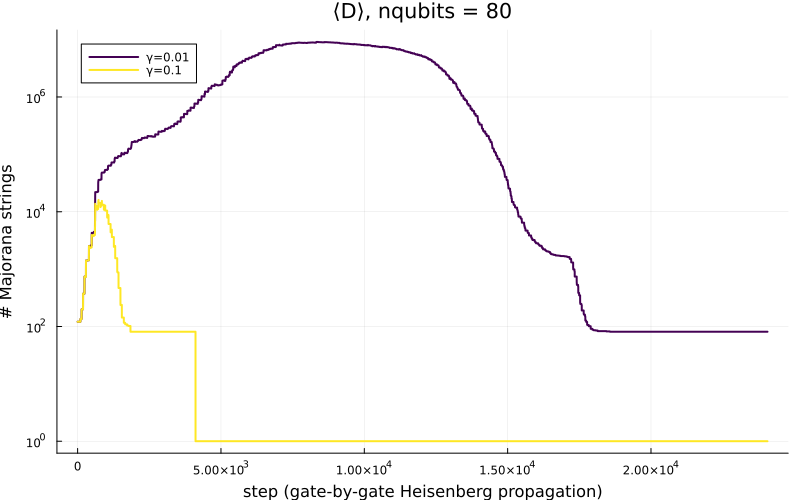

(Dict(0.01 => [121, 121, 121, 121, 121, 121, 121, 121, 121, 121  …  81, 81, 81, 81, 81, 81, 81, 81, 81, 81], 0.1 => [121, 121, 121, 121, 121, 121, 121, 121, 121, 121  …  1, 1, 1, 1, 1, 1, 1, 1, 1, 1]), Plot{Plots.GRBackend() n=2})

In [52]:
using Random, Plots

# ══════════════════════════════════════════════════════════════════════
# SHARED SETUP — run this once at the top of your notebook
# ══════════════════════════════════════════════════════════════════════
layers = schedule_into_layers(gates)
println("Circuit: $(length(gates)) MP-gates compressed into $(length(layers)) physical layers")
println("Average gates per layer: $(round(length(gates)/length(layers); digits=2))")

# Helper: run a sweep + plot for a single observable
function sweep_and_plot(
    obs_name::Symbol,
    obs_builder::Function,
    plot_title::String,
    gammas::Vector{Float64};
    min_abs_coeff::Float64 = 1e-10,
    yaxis_scale::Symbol    = :log10,
    legend_pos::Symbol     = :topleft,
    fname_prefix::String   = "growth",
)
    println("\n" * "="^60)
    println("Observable: $obs_name — $plot_title")
    println("="^60)

    # Run sweep
    curves = Dict{Float64, Vector{Int}}()
    for γ in gammas
        r = track_observable_growth_layered(
            gates, thetas, obs_builder, n_qubits;
            gamma         = γ,
            min_abs_coeff = min_abs_coeff,
        )
        curves[γ] = r.sizes
        println("  γ=$(rpad(γ, 10))  peak=$(rpad(maximum(curves[γ]), 7))  " *
                "final=$(curves[γ][end])")
    end

    # Plot
    palette = cgrad(:viridis, length(gammas); categorical=true)
    plt = plot(
        xlabel         = "step (gate-by-gate Heisenberg propagation)",
        ylabel         = "# Majorana strings",
        title          = plot_title,
        yaxis          = yaxis_scale,
        legend         = legend_pos,
        linewidth      = 2,
        size           = (800, 500),
        legendfontsize = 8,
    )
    for (k, γ) in enumerate(gammas)
        label = γ == 0.0 ? "no noise" : "γ=$γ"
        color = γ == 0.0 ? :black : palette[k]
        lw    = γ == 0.0 ? 2.5    : 2
        plot!(plt, 0:length(curves[γ])-1, curves[γ];
              label=label, color=color, linewidth=lw)
    end

    fname = "$(fname_prefix)_$(obs_name)_$(n_qubits).png"
    savefig(plt, fname)
    println("Saved: $fname")
    display(plt)

    return curves, plt
end


# ══════════════════════════════════════════════════════════════════════
# OBSERVABLE 1: Double Occupancy  (degree-4, sensitive to noise)
# ══════════════════════════════════════════════════════════════════════
gammas_D = [1e-2, 1e-1]  # [0.0, 1e-3 , 5e-3, 7e-3, 1e-2, 1.5e-2, 2e-2]

curves_D, plt_D = sweep_and_plot(
    :D,
    () -> build_average_double_occupancy(norb),
    "⟨D⟩, nqubits = $n_qubits",
    gammas_D;
    min_abs_coeff = 1e-9,
    yaxis_scale   = :log10,
    legend_pos    = :topleft,
)

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# OBSERVABLE 3: NN Coherence  (degree-2, off-diagonal)
# ══════════════════════════════════════════════════════════════════════
gammas_C1 = [0.0, 1e-3 , 5e-3, 7e-3, 1e-2, 1.5e-2, 2e-2]

curves_C1, plt_C1 = sweep_and_plot(
    :C1,
    () -> build_nn_coherence(norb),
    "Nearest-Neighbor Coherence ⟨C⁽¹⁾⟩",
    gammas_C1;
    min_abs_coeff = 1e-10,
    yaxis_scale   = :log10,
    legend_pos    = :topleft,
)

In [ ]:
# ══════════════════════════════════════════════════════════════════════
# OBSERVABLE 4: Site 1 Density  (degree-2, diagonal)
# ══════════════════════════════════════════════════════════════════════
gammas_n1 = [0.0, 1e-3 , 5e-3, 7e-3, 1e-2, 1.5e-2, 2e-2]

curves_n1, plt_n1 = sweep_and_plot(
    :n_1,
    () -> build_site_density(norb, 1),
    "Site 1 Density ⟨n₁⟩",
    gammas_n1;
    min_abs_coeff = 1e-10,
    yaxis_scale   = :log10,
    legend_pos    = :topleft,
)

# Expectation values accuracy prediction

In [ ]:
"""
    expectation_paper_model(gates, thetas, obs_builder, initial_state, n_qubits;
                            gamma, p_layer, mode, min_abs_coeff, rng)

Compute ⟨initial_state | U†·O·U | initial_state⟩ under the same noise model
used by `track_observable_growth_layered`. Returns the expectation value.

When `p_layer = 1.0` and `mode = :deterministic`, this is the paper's
per-layer depolarizing model and the result is deterministic.

When `p_layer < 1.0` or `mode = :per_qubit`, the result is stochastic and
should be averaged over `n_trajectories` calls outside this function (or
use `expectation_paper_model_mc` below for built-in averaging).
"""
function expectation_paper_model(gates, thetas, obs_builder, initial_state, n_qubits;
                                  gamma::Real         = 0.0,
                                  p_layer::Real       = 1.0,
                                  mode::Symbol        = :deterministic,
                                  min_abs_coeff::Real = 1e-14,
                                  rng                 = Random.GLOBAL_RNG)
    @assert mode in (:deterministic, :per_qubit) "mode must be :deterministic or :per_qubit"

    obs    = obs_builder()
    layers = schedule_into_layers(gates)

    # Heisenberg: walk layers in REVERSE order (matches growth function)
    for layer_idx in length(layers):-1:1
        # Apply all gates in this layer
        for k in layers[layer_idx]
            MP.propagate!([gates[k]], obs, [thetas[k]]; min_abs_coeff=min_abs_coeff)
        end

        # Decide whether the noise channel fires for this layer
        if gamma > 0 && rand(rng) < p_layer
            if mode === :deterministic
                apply_depolarizing_deterministic!(obs, gamma, min_abs_coeff)
            else  # :per_qubit
                apply_depolarizing_per_qubit!(obs, gamma, n_qubits, min_abs_coeff, rng)
            end
        end
    end

    # Evaluate ⟨Φ_0 | O_evolved | Φ_0⟩
    return real(MP.overlapwithfock(obs, initial_state))
end


"""
    expectation_paper_model_mc(gates, thetas, obs_builder, initial_state, n_qubits;
                                gamma, p_layer, mode, n_trajectories,
                                min_abs_coeff, rng)

Monte Carlo wrapper around `expectation_paper_model`. Auto-detects whether
the noise model is deterministic and short-circuits to a single evaluation
when it is, otherwise averages over `n_trajectories`.

Returns `(mean_value, std_err, all_values::Vector{Float64})`.
"""
function expectation_paper_model_mc(gates, thetas, obs_builder, initial_state, n_qubits;
                                     gamma::Real             = 0.0,
                                     p_layer::Real           = 1.0,
                                     mode::Symbol            = :deterministic,
                                     n_trajectories::Integer = 200,
                                     min_abs_coeff::Real     = 1e-14,
                                     rng                     = Random.GLOBAL_RNG)
    # Short-circuit: deterministic case is, well, deterministic
    deterministic = (gamma == 0.0) ||
                    (p_layer == 1.0 && mode === :deterministic)
    actual_n_traj = deterministic ? 1 : n_trajectories

    values = Float64[]
    for _ in 1:actual_n_traj
        v = expectation_paper_model(gates, thetas, obs_builder, initial_state, n_qubits;
                                     gamma=gamma, p_layer=p_layer, mode=mode,
                                     min_abs_coeff=min_abs_coeff, rng=rng)
        push!(values, v)
    end

    mean_val = mean(values)
    std_err  = actual_n_traj > 1 ? std(values) / sqrt(actual_n_traj) : 0.0
    return (mean_val, std_err, values)
end


In [ ]:
function sweep_expectation(
    obs_name::Symbol,
    obs_builder::Function,
    gammas::Vector{Float64},
    fock_state;
    p_layer::Real            = 1.0,
    mode::Symbol             = :deterministic,
    n_trajectories::Integer  = 200,
    min_abs_coeff::Float64   = 1e-14,
    plot_title::String       = "Expectation value vs noise",
    legend_pos::Symbol       = :bottomright,
    fname_prefix::String     = "expval",
    rng                      = Random.GLOBAL_RNG,
)
    println("\n" * "="^60)
    println("Expectation sweep: $obs_name — $plot_title")
    println("  noise model: p_layer=$p_layer, mode=$mode")
    println("="^60)

    # Ensure γ = 0 is always present
    if !(0.0 in gammas)
        gammas = vcat(0.0, gammas)
    end
    gammas = sort(unique(gammas))

    values = Dict{Float64, Float64}()
    errors = Dict{Float64, Float64}()  # standard errors when stochastic

    for γ in gammas
        mean_val, std_err, _ = expectation_paper_model_mc(
            gates, thetas, obs_builder, fock_state, n_qubits;
            gamma          = γ,
            p_layer        = p_layer,
            mode           = mode,
            n_trajectories = n_trajectories,
            min_abs_coeff  = min_abs_coeff,
            rng            = rng,
        )
        values[γ] = mean_val
        errors[γ] = std_err

        if std_err > 0
            println("  γ=$(rpad(γ, 10))  ⟨$obs_name⟩ = $(round(mean_val; digits=8))" *
                    " ± $(round(std_err; sigdigits=2))")
        else
            println("  γ=$(rpad(γ, 10))  ⟨$obs_name⟩ = $(round(mean_val; digits=8))")
        end
    end

    # Sort for plotting
    γ_sorted = sort(collect(keys(values)))
    v_sorted = [values[γ] for γ in γ_sorted]
    e_sorted = [errors[γ] for γ in γ_sorted]
    ref_value = values[0.0]

    # Use error bars if any are non-zero
    has_errors = any(e -> e > 0, e_sorted)

    plt = plot(
        γ_sorted, v_sorted;
        xlabel         = "noise level γ",
        ylabel         = "⟨$(obs_name)⟩",
        title          = plot_title,
        xaxis          = :log10,
        marker         = :circle,
        markersize     = 6,
        linewidth      = 2,
        yerror         = has_errors ? e_sorted : nothing,
        label          = "computed",
        legend         = legend_pos,
        size           = (800, 500),
        legendfontsize = 9,
    )

    hline!(plt, [ref_value]; label="γ=0 reference",
           linestyle=:dash, color=:black, linewidth=1.5)

    fname = "$(fname_prefix)_$(obs_name).png"
    savefig(plt, fname)
    println("Saved: $fname")
    display(plt)

    return values, errors, plt
end

In [ ]:
fock_state = [1, 1, 0, 0,    # spin-up
              1, 1, 0, 0]    # spin-down

gammas_default = [0.0, 1e-3, 5e-3, 7e-3, 1e-2, 1.5e-2, 2e-2]


# ── Observable 1: Double Occupancy ──────────────────────────────────────
vals_D, errs_D, plt_eD = sweep_expectation(
    :D,
    () -> build_average_double_occupancy(norb),
    copy(gammas_default),
    fock_state;
    plot_title = "⟨D⟩ vs noise level",
    legend_pos = :topright,
)


# ── Observable 2: NN Coherence ─────────────────────────────────────────
vals_C1, errs_C1, plt_eC1 = sweep_expectation(
    :C1,
    () -> build_nn_coherence(norb),
    copy(gammas_default),
    fock_state;
    plot_title = "⟨C⁽¹⁾⟩ vs noise level",
    legend_pos = :topright,
)


# ── Observable 3: Site 1 Density ───────────────────────────────────────
vals_n1, errs_n1, plt_en1 = sweep_expectation(
    :n_1,
    () -> build_site_density(norb, 1),
    copy(gammas_default),
    fock_state;
    plot_title = "⟨n₁⟩ vs noise level",
    legend_pos = :topright,
)